# Attack/defense bivariate-Poisson models for World Cup scores

**Deep dive.** This notebook builds a *factorial state-space model* (fSSM) of
international football that predicts **scorelines** for the 2026 FIFA World Cup,
following the [`cuthberto-carlos`](https://github.com/state-space-models/cuthberto-carlos)
formulation. It extends the win/draw/loss skill model with a richer
**attack/defense** state and a **bivariate Poisson** goal likelihood.

Each team carries a *two-dimensional* latent skill — attacking and defensive
strength — that evolves as Brownian motion, and a match's scoreline is modelled
with the bivariate Poisson distribution of
[Karlis & Ntzoufras (2003)](https://doi.org/10.1111/1467-9884.00366) (Duffield et al.
2024, §4.6):

$$
\begin{aligned}
p(x^i_0) &= \mathrm N(\mu_0, \Sigma_0), &
p(x^i_k \mid x^i_{k-1}) &= \mathrm N\!\big(x^i_{k-1}, \tau^2 (t_k - t_{k-1})\big), \\[2pt]
p(y_k \mid x^i_k, x^j_k) &= \mathrm{BivariatePoisson}(y_k \mid \lambda_1, \lambda_2, \lambda_3),
\end{aligned}
$$

with $x^i = (x^{\mathrm{att},i}, x^{\mathrm{def},i})$, scoreline $y_k = (y^i_k, y^j_k)$, and rates

$$
\lambda_1 = e^{\alpha + x^{\mathrm{att},i} - x^{\mathrm{def},j}},\quad
\lambda_2 = e^{\alpha + x^{\mathrm{att},j} - x^{\mathrm{def},i}},\quad
\lambda_3 = e^{\beta}.
$$

$\lambda_1,\lambda_2$ are the two teams' scoring rates (own attack vs the opponent's
defense); $\lambda_3$ is a shared-goals correlation term. We reuse the same
`FactorialDynamicalModel` + `dsx.sample` machinery as the scalar model — only the
per-factor state dimension (`2`) and the observation model change.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import numpyro.distributions as dist
from numpyro.infer import Predictive

import dynestyx as dsx
from dynestyx import (
    FactorialDynamicalModel,
    RandomWalkEvolution,
    BivariatePoissonScoreObservation,
    BivariatePoisson,
    Filter,
    Smoother,
    FactorialEKFConfig,
    FactorialEKFSmootherConfig,
    factorial_score_probabilities,
)

jax.config.update("jax_enable_x64", True)

## 1. Data: scorelines and the 2026 World Cup fixtures

We download Mart Jürisoo's open
[`international_results`](https://github.com/martj42/international_results) dataset at
runtime; it already contains the **2026 World Cup fixtures** as future rows with
missing scores. As before we focus on the 48 World Cup teams and their head-to-head
matches since 2015, but now the observations are the **scorelines**
`(home_goals, away_goals)` rather than win/draw/loss labels.

In [2]:
URL = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"
df = pd.read_csv(URL, parse_dates=["date"])

future = df[
    df["home_score"].isna()
    & (df["tournament"] == "FIFA World Cup")
    & (df["date"] >= "2026-06-01")
].sort_values("date")
wc_teams = sorted(set(future["home_team"]) | set(future["away_team"]))
team_idx = {t: i for i, t in enumerate(wc_teams)}
F = len(wc_teams)

played = df.dropna(subset=["home_score", "away_score"]).copy()
played = played[
    (played["date"] >= "2015-01-01")
    & played["home_team"].isin(team_idx)
    & played["away_team"].isin(team_idx)
].sort_values("date").reset_index(drop=True)

t0_date = played["date"].min()
K = len(played)
days = (played["date"] - t0_date).dt.days.to_numpy().astype(float)
# Time in years, plus a tiny ramp so identical dates are strictly increasing.
obs_times = jnp.asarray(days / 365.25 + np.arange(K) * 1e-6)
obs_factor_indices = jnp.asarray(
    np.stack(
        [
            played["home_team"].map(team_idx).to_numpy(),
            played["away_team"].map(team_idx).to_numpy(),
        ],
        axis=1,
    ).astype(np.int32)
)
# Observations are scorelines (home_goals, away_goals).
obs_values = jnp.asarray(
    np.stack(
        [played["home_score"].to_numpy(), played["away_score"].to_numpy()], axis=1
    ).astype(np.int32)
)
MAX_GOALS = int(max(played["home_score"].max(), played["away_score"].max())) + 8

print(f"{F} teams, {K} historical scorelines, {len(future)} World Cup fixtures to predict")
print(f"max goals in a match: {int(max(played['home_score'].max(), played['away_score'].max()))}")

48 teams, 1314 historical scorelines, 72 World Cup fixtures to predict
max goals in a match: 7


## 2. The bivariate-Poisson factorial model

The per-factor state is now 2-D `(attack, defense)`, so the initial condition is a
bivariate Gaussian and the random walk has a (per-dimension) drift rate $\tau$. The
observation is `BivariatePoissonScoreObservation`, which maps the two teams'
attack/defense skills to the bivariate-Poisson rates above. Hyperparameters
($\alpha$ baseline scoring, $\beta$ correlation, $\tau$ drift, $\sigma_0$ initial
spread) are illustrative, tuned offline for sensible ratings.

In [3]:
ALPHA = 0.25       # baseline log scoring rate (exp(0.25) ~ 1.3 goals)
BETA = -1.5         # log shared-goals correlation (lambda3 = exp(beta) ~ 0.22)
TAU = 0.4           # attack/defense drift rate (per sqrt-year)
SIGMA0 = 0.5        # initial attack/defense standard deviation

D = 2  # (attack, defense) per team


def build_model(tau=TAU, alpha=ALPHA, beta=BETA, sigma0=SIGMA0):
    return FactorialDynamicalModel(
        initial_condition=dist.MultivariateNormal(jnp.zeros(D), sigma0**2 * jnp.eye(D)),
        state_evolution=RandomWalkEvolution(
            tau=jnp.array([tau, tau]), factor_state_dim=D
        ),
        observation_model=BivariatePoissonScoreObservation(
            alpha=alpha, beta=beta, factor_state_dim=D, max_goals=MAX_GOALS
        ),
        num_factors=F,
        num_local_factors=2,
        t0=0.0,
    )


def world_cup_model(tau=TAU, predict_times=None, predict_factor_indices=None):
    with Filter(filter_config=FactorialEKFConfig(record_filtered_states_mean=True)):
        dsx.sample(
            "skill",
            build_model(tau=tau),
            obs_times=obs_times,
            obs_values=obs_values,
            obs_factor_indices=obs_factor_indices,
            predict_times=predict_times,
            predict_factor_indices=predict_factor_indices,
        )

## 3. Filtering: attack & defense ratings

Filtering records each team's current 2-D skill $\mathbb E[x^f_t \mid y_{1:t}] =
(\text{attack}, \text{defense})$. Higher attack means more goals scored; higher
defense means fewer conceded (it enters opponents' rates as $-x^{\mathrm{def}}$), so
we rank by overall strength = attack + defense.

In [4]:
trace = Predictive(world_cup_model, num_samples=1)(jax.random.PRNGKey(0))
skills = np.asarray(trace["skill_filtered_states_mean"][0])  # (F, 2)
attack, defense = skills[:, 0], skills[:, 1]
overall = attack + defense
print(f"marginal log-likelihood (EKF evidence): {float(trace['skill_marginal_loglik'][0]):.1f}")

order = np.argsort(overall)[::-1]
ranking = pd.DataFrame(
    {
        "team": [wc_teams[i] for i in order],
        "attack": attack[order],
        "defense": defense[order],
        "overall": overall[order],
    }
)
ranking.index = np.arange(1, F + 1)
ranking.head(15).round(3)

marginal log-likelihood (EKF evidence): -3240.2


,team,attack,defense,overall
1,Portugal,0.432,0.644,1.076
2,Brazil,0.498,0.525,1.023
3,Argentina,0.151,0.671,0.822
4,Spain,0.370,0.437,0.807
5,France,0.344,0.448,0.793
6,Belgium,0.497,0.150,0.648
7,Morocco,0.058,0.585,0.644
8,Japan,0.097,0.489,0.586
9,Colombia,0.243,0.340,0.583
10,Netherlands,0.340,0.227,0.567


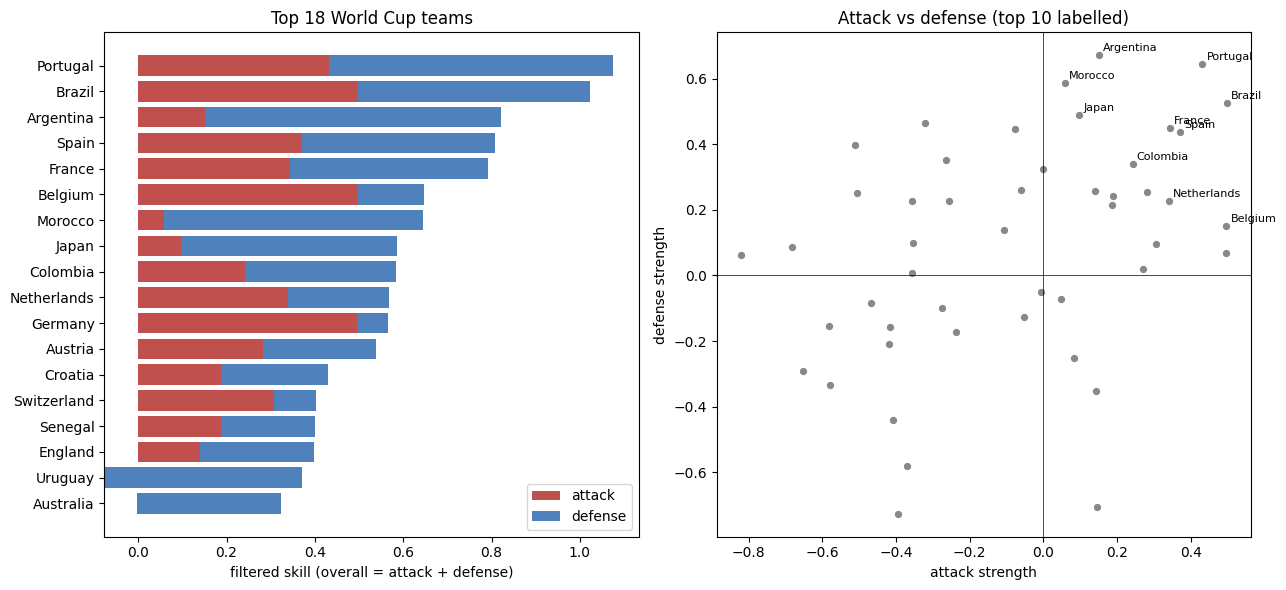

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

top = 18
to = order[:top][::-1]
ax = axes[0]
ax.barh([wc_teams[i] for i in to], attack[to], color="#c0504d", label="attack")
ax.barh([wc_teams[i] for i in to], defense[to], left=attack[to], color="#4f81bd", label="defense")
ax.set_xlabel("filtered skill (overall = attack + defense)")
ax.set_title(f"Top {top} World Cup teams")
ax.legend(loc="lower right")

ax = axes[1]
ax.scatter(attack, defense, s=18, color="#888")
for i in order[:10]:
    ax.annotate(wc_teams[i], (attack[i], defense[i]), fontsize=8,
                xytext=(3, 3), textcoords="offset points")
ax.axhline(0, color="k", lw=0.5); ax.axvline(0, color="k", lw=0.5)
ax.set_xlabel("attack strength"); ax.set_ylabel("defense strength")
ax.set_title("Attack vs defense (top 10 labelled)")
fig.tight_layout()
plt.show()

## 4. Smoothing: attack & defense trajectories

Smoothing conditions each estimate on the full history. We plot the smoothed
attack and defense strengths over time for a few teams (solid = attack,
dashed = defense).

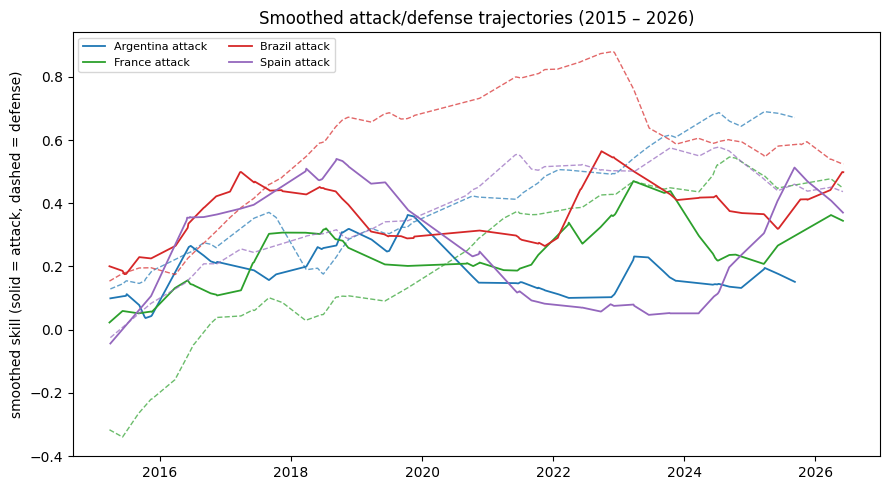

In [6]:
def smoothed_model():
    with Smoother(
        smoother_config=FactorialEKFSmootherConfig(record_smoothed_states_mean=True)
    ):
        dsx.sample(
            "skill",
            build_model(),
            obs_times=obs_times,
            obs_values=obs_values,
            obs_factor_indices=obs_factor_indices,
        )


strace = Predictive(smoothed_model, num_samples=1)(jax.random.PRNGKey(0))
smoothed_local = np.asarray(strace["skill_smoothed_local_states_mean"][0])  # (K, 2, 2)
idx_np = np.asarray(obs_factor_indices)
match_dates = played["date"].to_numpy()


def team_trajectory(team):
    i = team_idx[team]
    dates, att, dfn = [], [], []
    for k in range(K):
        for j in range(2):
            if idx_np[k, j] == i:
                dates.append(match_dates[k])
                att.append(smoothed_local[k, j, 0])
                dfn.append(smoothed_local[k, j, 1])
    return np.array(dates), np.array(att), np.array(dfn)


fig, ax = plt.subplots(figsize=(9, 5))
for team, color in zip(
    ["Argentina", "France", "Brazil", "Spain"],
    ["#1f77b4", "#2ca02c", "#d62728", "#9467bd"],
):
    if team in team_idx:
        d_, a_, f_ = team_trajectory(team)
        ax.plot(d_, a_, "-", color=color, lw=1.3, label=f"{team} attack")
        ax.plot(d_, f_, "--", color=color, lw=1.0, alpha=0.7)
ax.set_ylabel("smoothed skill (solid = attack, dashed = defense)")
ax.set_title("Smoothed attack/defense trajectories (2015 – 2026)")
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
plt.show()

## 5. Choosing $\tau$ from the marginal likelihood

As before, the `Filter` exposes the marginal likelihood, which we profile over the
drift rate $\tau$ to pick how fast skills move. The factorial EKF marginal likelihood
is a Gaussian/Laplace approximation of a discrete evidence, so its absolute value is
not a calibrated log-loss — read it only as a **relative** criterion across $\tau$,
and use `FactorialPFConfig` for gradient-based parameter inference.

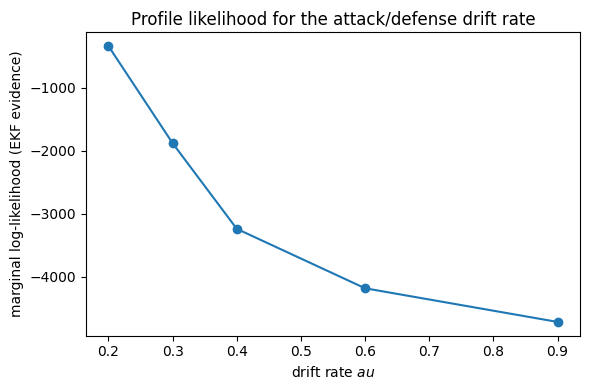

relative best tau: 0.2


In [7]:
from dynestyx.inference.integrations.cuthbert.factorial_filter import (
    compute_factorial_filter,
)

taus = np.array([0.2, 0.3, 0.4, 0.6, 0.9])
logliks = []
for tau in taus:
    ll, *_ = compute_factorial_filter(
        build_model(tau=float(tau)),
        FactorialEKFConfig(),
        None,
        obs_times=obs_times,
        obs_values=obs_values,
        obs_factor_indices=obs_factor_indices,
    )
    logliks.append(float(ll))
logliks = np.array(logliks)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(taus, logliks, "o-")
ax.set_xlabel(r"drift rate $	au$")
ax.set_ylabel("marginal log-likelihood (EKF evidence)")
ax.set_title("Profile likelihood for the attack/defense drift rate")
fig.tight_layout()
plt.show()
print("relative best tau:", float(taus[int(np.argmax(logliks))]))

## 6. Predicting World Cup scorelines

For each fixture we propagate the two teams' filtered attack/defense skills to the
match date and integrate the bivariate-Poisson likelihood over the predictive skill
distribution (`factorial_score_probabilities`). This yields, per match, a **score
grid** $p(\text{home }a,\ \text{away }b)$ and the implied **win/draw/loss**
probabilities.

In [8]:
pred_dates = future["date"].to_numpy()
P = len(future)
predict_times = jnp.asarray(
    (future["date"] - t0_date).dt.days.to_numpy().astype(float) / 365.25
    + np.arange(P) * 1e-6
)
predict_factor_indices = jnp.asarray(
    np.stack(
        [
            future["home_team"].map(team_idx).to_numpy(),
            future["away_team"].map(team_idx).to_numpy(),
        ],
        axis=1,
    ).astype(np.int32)
)


def predict_model():
    world_cup_model(
        predict_times=predict_times,
        predict_factor_indices=predict_factor_indices,
    )


ptrace = Predictive(predict_model, num_samples=1)(jax.random.PRNGKey(0))
pred_means = ptrace["skill_predicted_states"][0]           # (P, 2, 2)
pred_chols = ptrace["skill_predicted_states_chol_cov"][0]  # (P, 2, 2, 2)

GRID = 6
score_grids, wdl = factorial_score_probabilities(
    BivariatePoissonScoreObservation(
        alpha=ALPHA, beta=BETA, factor_state_dim=D, max_goals=MAX_GOALS
    ),
    pred_means,
    pred_chols,
    key=jax.random.PRNGKey(1),
    n_samples=4000,
    max_goals_grid=GRID,
)
score_grids = np.asarray(score_grids)
wdl = np.asarray(wdl)

# Expected goals per team from the score grid.
exp_home = (score_grids.sum(2) * np.arange(GRID + 1)).sum(1)
exp_away = (score_grids.sum(1) * np.arange(GRID + 1)).sum(1)

predictions = pd.DataFrame(
    {
        "date": pd.to_datetime(pred_dates).strftime("%Y-%m-%d"),
        "home": future["home_team"].to_numpy(),
        "away": future["away_team"].to_numpy(),
        "P(home win)": wdl[:, 0],
        "P(draw)": wdl[:, 1],
        "P(away win)": wdl[:, 2],
        "exp_home_goals": exp_home,
        "exp_away_goals": exp_away,
    }
)
predictions.round(2).head(16)

,date,home,away,P(home win),P(draw),P(away win),exp_home_goals,exp_away_goals
0,2026-06-11,Mexico,South Africa,0.42,0.35,0.23,1.19,0.84
1,2026-06-11,South Korea,Czech Republic,0.51,0.25,0.24,1.78,1.18
2,2026-06-12,Canada,Bosnia and Herzegovina,0.50,0.30,0.21,1.47,0.91
3,2026-06-12,United States,Paraguay,0.34,0.30,0.36,1.22,1.27
4,2026-06-13,Qatar,Switzerland,0.09,0.13,0.78,0.96,2.76
5,2026-06-13,Brazil,Morocco,0.44,0.30,0.26,1.42,1.06
6,2026-06-13,Haiti,Scotland,0.18,0.21,0.61,1.18,2.20
7,2026-06-13,Australia,Turkey,0.52,0.24,0.25,1.90,1.28
8,2026-06-14,Sweden,Tunisia,0.39,0.26,0.36,1.58,1.51
9,2026-06-14,Netherlands,Japan,0.36,0.28,0.36,1.37,1.38


### Score-grid heatmaps for selected fixtures

Each grid shows $p(\text{home scores } a,\ \text{away scores } b)$, capped at
$6\!-\!6$ (the bivariate-Poisson "score grid" of the cuthberto-carlos README).

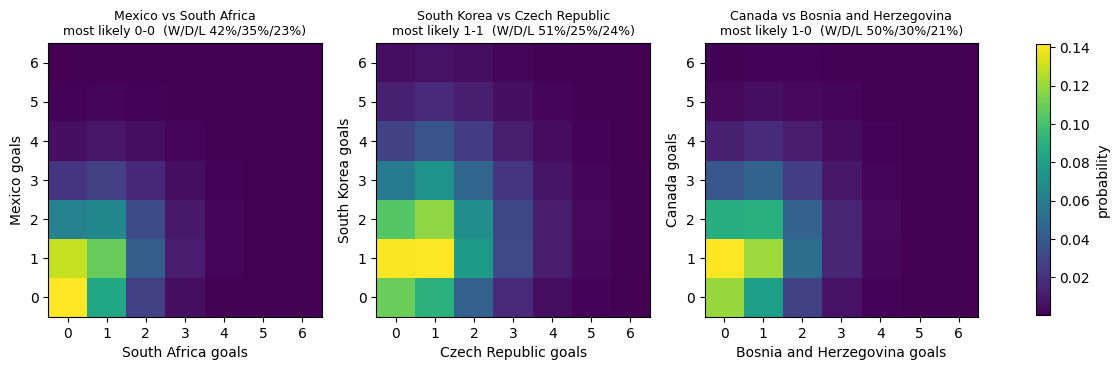

In [9]:
def show_fixture(ax, p):
    g = score_grids[p]
    im = ax.imshow(g, origin="lower", cmap="viridis")
    ax.set_xlabel(f"{future['away_team'].iloc[p]} goals")
    ax.set_ylabel(f"{future['home_team'].iloc[p]} goals")
    ax.set_xticks(range(GRID + 1)); ax.set_yticks(range(GRID + 1))
    best = np.unravel_index(np.argmax(g), g.shape)
    ax.set_title(
        f"{future['home_team'].iloc[p]} vs {future['away_team'].iloc[p]}\n"
        f"most likely {best[0]}-{best[1]}  "
        f"(W/D/L {wdl[p,0]:.0%}/{wdl[p,1]:.0%}/{wdl[p,2]:.0%})",
        fontsize=9,
    )
    return im


n_show = min(3, P)
fig, axes = plt.subplots(1, n_show, figsize=(5 * n_show, 4.4))
axes = np.atleast_1d(axes)
for ax, p in zip(axes, range(n_show)):
    im = show_fixture(ax, p)
fig.colorbar(im, ax=list(axes), shrink=0.8, label="probability")
plt.show()

## 7. Discussion

This notebook upgraded the factorial skill model from win/draw/loss to a full
**scoreline** model: each team carries a 2-D attack/defense state and matches are
generated by a **bivariate Poisson** likelihood (the novel distribution implemented as
`dynestyx.BivariatePoisson`). The same `FactorialDynamicalModel` + `dsx.sample`
interface drove filtering (attack/defense ratings), smoothing (trajectories), and
predictive scorelines — only the per-factor dimension and the observation model
changed.

Notes and extensions:

- **Attack vs defense.** The 2-D state separates *scoring* from *conceding*; the score
  grid and expected goals follow directly from the bivariate-Poisson rates.
- **Correlation.** $\lambda_3 = e^\beta$ captures the tendency for goals to come in
  pairs; setting $\beta \to -\infty$ recovers two independent Poissons.
- **Inference.** As with the scalar model, the EKF is forward-only (the score
  potential's Hessian is rank-deficient in the 4-D joint state); use
  `FactorialPFConfig` for gradient-based parameter inference, and read the EKF
  marginal likelihood only as a relative diagnostic.
- **Further modelling.** Neutral-venue / home-advantage terms, Ornstein–Uhlenbeck
  (mean-reverting) skill dynamics, and full parameter inference over
  $(\mu_0, \Sigma_0, \tau, \alpha, \beta)$ all fit the same interface — planned for
  follow-up work.